# 05 — Exploratory Data Analysis (EDA): German Day-Ahead Electricity Prices

## EDA storyline

The notebook answers five questions:

1. How did day-ahead prices evolve from 2022–2024?
2. How unusual, volatile or extreme are electricity prices?
3. How do prices vary by hour, weekday, month and year?
4. How are prices related to load and renewable generation?
5. Which features deserve closer attention during model development?

> **Important:** A normal logarithm is not suitable because electricity prices can be zero or negative. This notebook uses an `asinh` transformation. It behaves similarly to a log transformation for large values while remaining valid for zero and negative prices.


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.frameon": True,
    "figure.autolayout": True
})


## 1. Configure file locations

In [4]:
PROJECT_ROOT = Path(r"C:\Users\SherM\OneDrive\Documents\1. Thesis")

DATA_PATH = PROJECT_ROOT / "Dataset" / "Merged_dataset" / "master_dataset.parquet"
FIGURE_DIR = PROJECT_ROOT / "Figures" / "EDA_v2"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset path:", DATA_PATH)
print("Figure folder:", FIGURE_DIR)


Dataset path: C:\Users\SherM\OneDrive\Documents\1. Thesis\Dataset\Merged_dataset\master_dataset.parquet
Figure folder: C:\Users\SherM\OneDrive\Documents\1. Thesis\Figures\EDA_v2


## 2. Load and validate the master dataset

In [6]:
df = pd.read_parquet(DATA_PATH).sort_index()

print(df.info())
print("\nShape:", df.shape)
print("\nIndex timezone:", df.index.tz)
print("\nDuplicate timestamps:", df.index.duplicated().sum())
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

# German local time for EDA charts
# Keep the stored dataset unchanged.
df_eda = df.copy()
df_eda.index = df_eda.index.tz_convert("Europe/Berlin")

df_eda["local_hour"] = df_eda.index.hour
df_eda["weekday_number"] = df_eda.index.dayofweek
df_eda["weekday_name"] = pd.Categorical(
    df_eda.index.day_name(),
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True
)
df_eda["month_number"] = df_eda.index.month
df_eda["month_name"] = pd.Categorical(
    df_eda.index.month_name().str[:3],
    categories=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"],
    ordered=True
)
df_eda["year"] = df_eda.index.year
df_eda["date"] = df_eda.index.date

required = ["day_ahead_price", "load", "solar_generation", "wind_generation", "renewable_share"]
missing = [c for c in required if c not in df_eda.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

print("\nEDA dataset successfully loaded.")


<class 'pandas.DataFrame'>
DatetimeIndex: 26112 entries, 2022-01-07 23:00:00+00:00 to 2024-12-30 22:00:00+00:00
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   day_ahead_price       26112 non-null  float64
 1   lag_1                 26112 non-null  float64
 2   lag_24                26112 non-null  float64
 3   lag_168               26112 non-null  float64
 4   rolling_mean_24       26112 non-null  float64
 5   rolling_std_24        26112 non-null  float64
 6   price_diff            26112 non-null  float64
 7   volatility_24         26112 non-null  float64
 8   hour                  26112 non-null  int32  
 9   day_of_week           26112 non-null  int32  
 10  month                 26112 non-null  int32  
 11  is_weekend            26112 non-null  int64  
 12  hour_sin              26112 non-null  float64
 13  hour_cos              26112 non-null  float64
 14  load                  26112 non-nu

## 3. Create analysis variables

In [8]:
price_col = "day_ahead_price"

df_eda["price_asinh"] = np.arcsinh(df_eda[price_col])
df_eda["is_negative_price"] = df_eda[price_col] < 0

spike_threshold = df_eda[price_col].quantile(0.99)
df_eda["is_price_spike"] = df_eda[price_col] >= spike_threshold

daily_price = df_eda[price_col].resample("D").agg(
    daily_mean="mean",
    daily_median="median",
    daily_min="min",
    daily_max="max"
)
daily_price["rolling_mean_7d"] = daily_price["daily_mean"].rolling(7).mean()
daily_price["rolling_mean_30d"] = daily_price["daily_mean"].rolling(30).mean()

print(f"99th percentile spike threshold: {spike_threshold:.2f} EUR/MWh")
print(f"Negative-price hours: {df_eda['is_negative_price'].sum():,}")
print(f"Share of negative-price hours: {df_eda['is_negative_price'].mean():.2%}")


99th percentile spike threshold: 563.81 EUR/MWh
Negative-price hours: 823
Share of negative-price hours: 3.15%


## 4. Figure-saving helper

In [10]:
def save_and_show(fig, filename: str) -> None:
    output_path = FIGURE_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {output_path}")


# Part A — Market evolution and price behaviour

## Figure 1. Daily average prices and 30-day trend

**Question:** How did German day-ahead electricity prices evolve across 2022–2024?

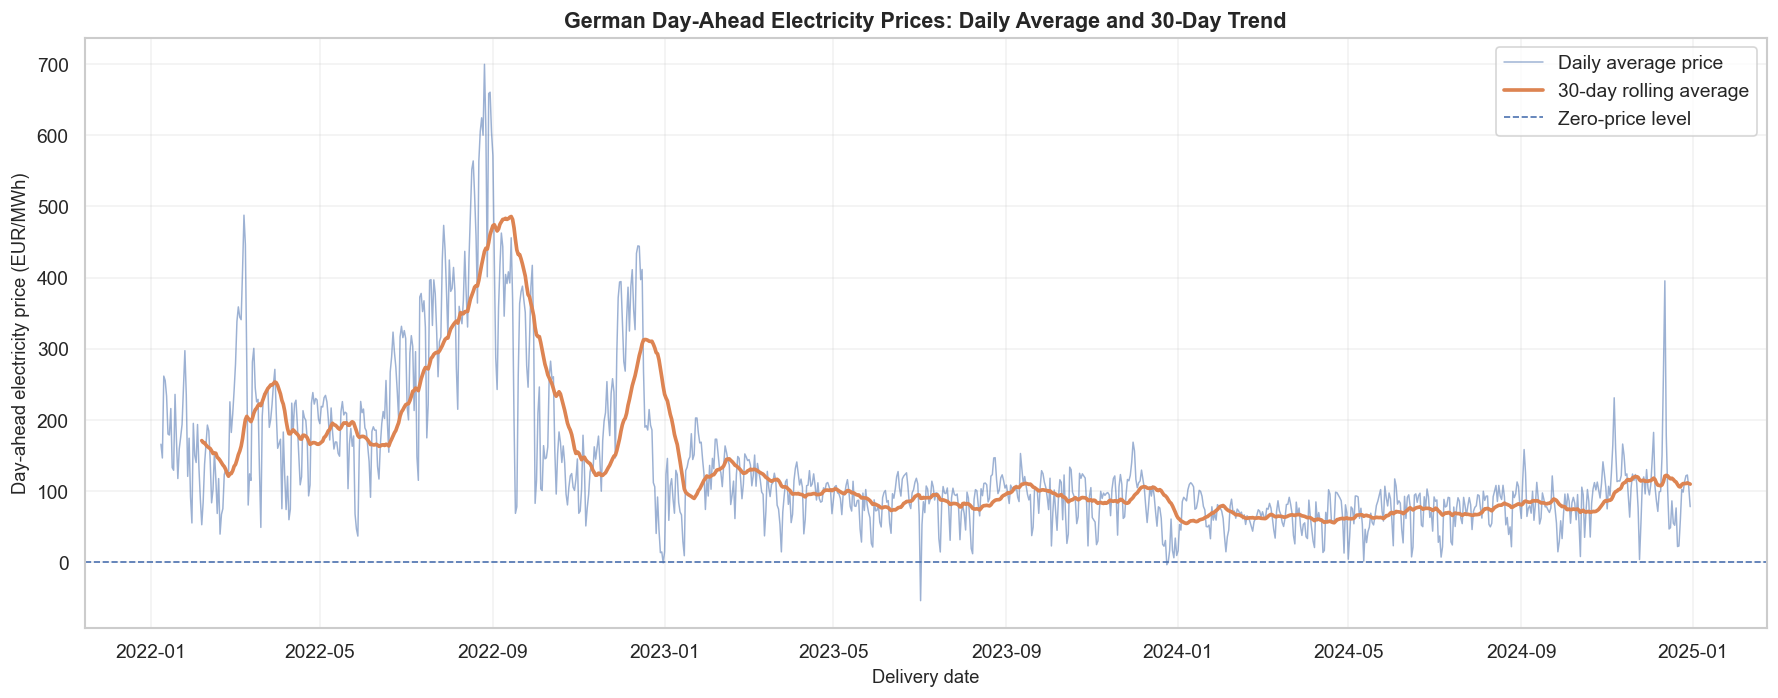

Saved: C:\Users\SherM\OneDrive\Documents\1. Thesis\Figures\EDA_v2\01_daily_price_trend.png


In [12]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(daily_price.index, daily_price["daily_mean"], linewidth=0.9, alpha=0.55, label="Daily average price")
ax.plot(daily_price.index, daily_price["rolling_mean_30d"], linewidth=2.2, label="30-day rolling average")
ax.axhline(0, linewidth=1, linestyle="--", label="Zero-price level")
ax.set_title("German Day-Ahead Electricity Prices: Daily Average and 30-Day Trend")
ax.set_xlabel("Delivery date")
ax.set_ylabel("Day-ahead electricity price (EUR/MWh)")
ax.legend()
ax.grid(alpha=0.25)
save_and_show(fig, "01_daily_price_trend.png")


## Figure 2. Raw and transformed price distributions

**Question:** What prices occur most frequently and how extreme are the tails?

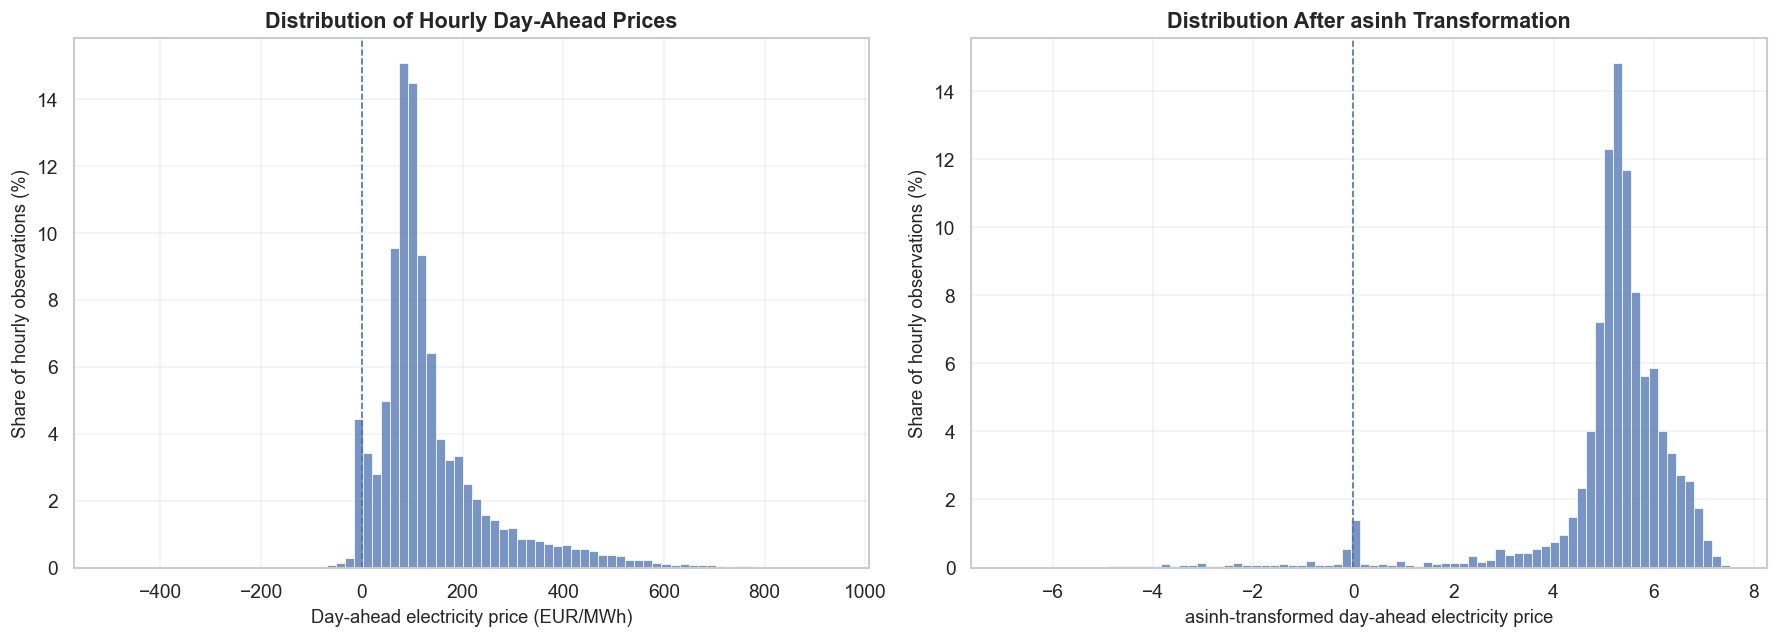

Saved: C:\Users\SherM\OneDrive\Documents\1. Thesis\Figures\EDA_v2\03_price_distribution_raw_and_asinh.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
weights = np.ones(len(df_eda)) / len(df_eda) * 100

sns.histplot(x=df_eda[price_col], bins=80, weights=weights, ax=axes[0])
axes[0].set_title("Distribution of Hourly Day-Ahead Prices")
axes[0].set_xlabel("Day-ahead electricity price (EUR/MWh)")
axes[0].set_ylabel("Share of hourly observations (%)")
axes[0].axvline(0, linestyle="--", linewidth=1)

sns.histplot(x=df_eda["price_asinh"], bins=80, weights=weights, ax=axes[1])
axes[1].set_title("Distribution After asinh Transformation")
axes[1].set_xlabel("asinh-transformed day-ahead electricity price")
axes[1].set_ylabel("Share of hourly observations (%)")
axes[1].axvline(0, linestyle="--", linewidth=1)

for ax in axes:
    ax.grid(alpha=0.25)

save_and_show(fig, "03_price_distribution_raw_and_asinh.png")


# Part B — Temporal patterns

## Figure 3. Hour-of-week price heatmap

**Question:** Which combinations of weekday and delivery hour are typically expensive?

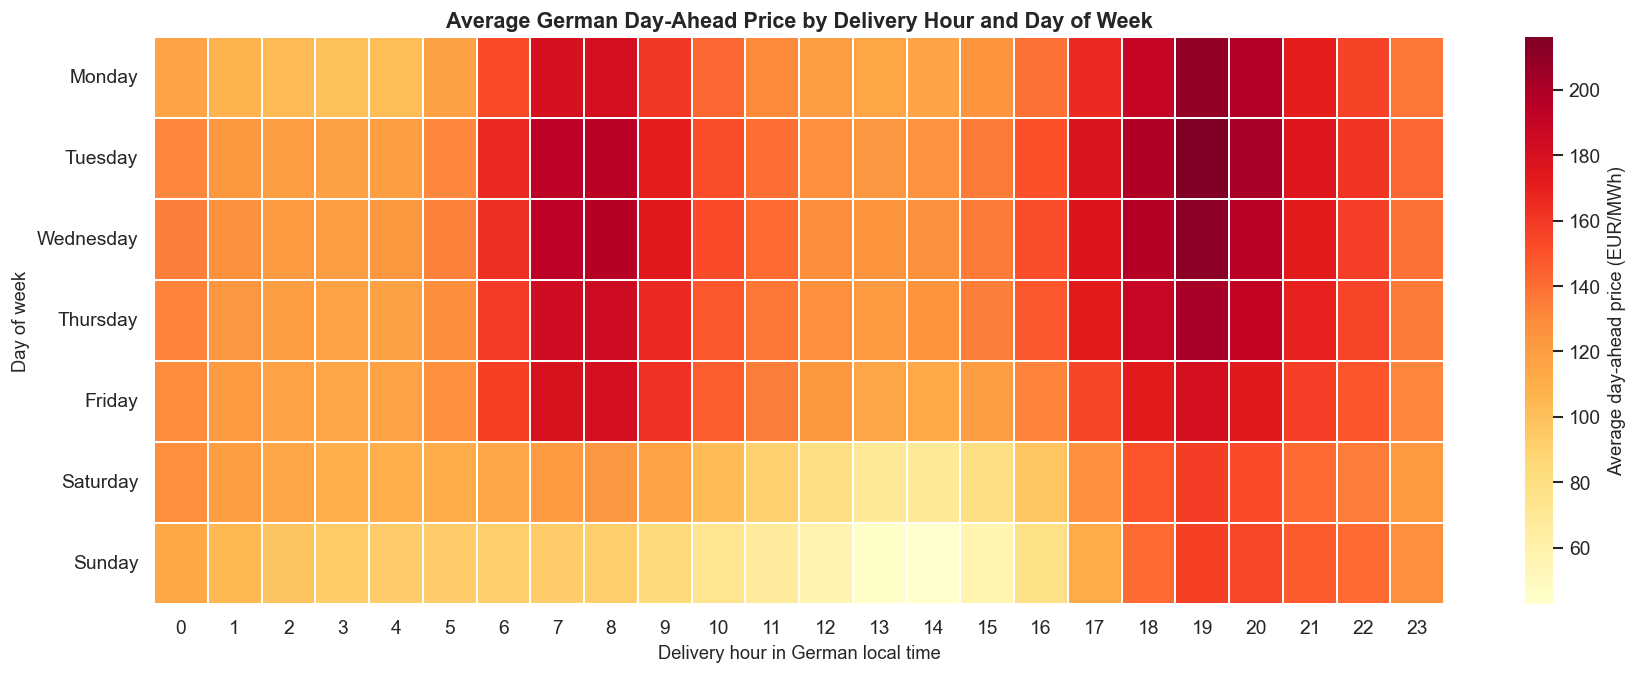

Saved: C:\Users\SherM\OneDrive\Documents\1. Thesis\Figures\EDA_v2\05_hour_of_week_price_heatmap.png


In [16]:
hour_week_matrix = df_eda.pivot_table(index="weekday_name", columns="local_hour", values=price_col, aggfunc="mean")

fig, ax = plt.subplots(figsize=(15, 5.8))
sns.heatmap(
    hour_week_matrix,
    cmap="YlOrRd",
    linewidths=0.25,
    cbar_kws={"label": "Average day-ahead price (EUR/MWh)"},
    ax=ax
)
ax.set_title("Average German Day-Ahead Price by Delivery Hour and Day of Week")
ax.set_xlabel("Delivery hour in German local time")
ax.set_ylabel("Day of week")
save_and_show(fig, "05_hour_of_week_price_heatmap.png")


## Figure 4. Monthly average price pattern by year

**Question:** How did seasonality and year-specific market conditions differ across 2022, 2023 and 2024?


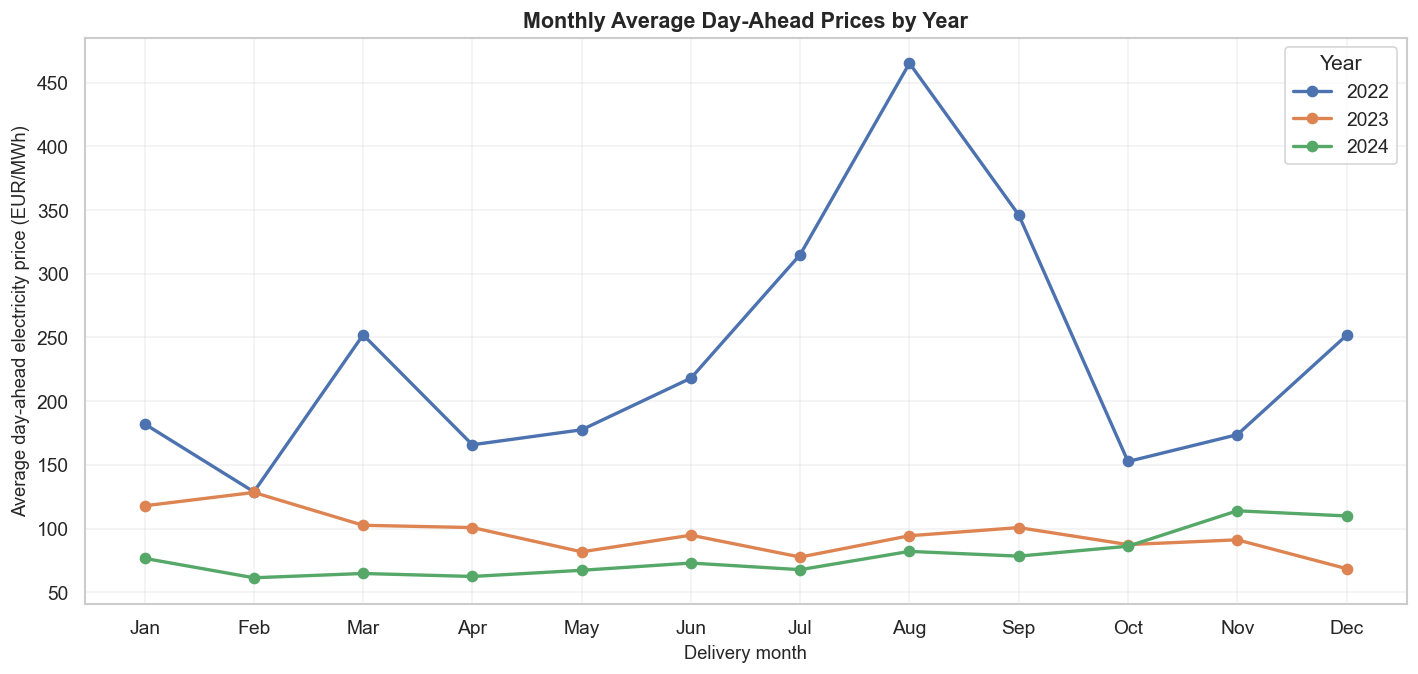

Saved: C:\Users\SherM\OneDrive\Documents\1. Thesis\Figures\EDA_v2\07_monthly_average_price_by_year.png


In [18]:
monthly_year_price = df_eda.groupby(["year", "month_number"])[price_col].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5.8))
for year, group in monthly_year_price.groupby("year"):
    ax.plot(group["month_number"], group[price_col], marker="o", linewidth=2, label=str(year))

ax.set_title("Monthly Average Day-Ahead Prices by Year")
ax.set_xlabel("Delivery month")
ax.set_ylabel("Average day-ahead electricity price (EUR/MWh)")
ax.set_xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.legend(title="Year")
ax.grid(alpha=0.25)
save_and_show(fig, "07_monthly_average_price_by_year.png")


# Part C — Fundamental drivers

## Helper function for binned relationship charts

In [20]:
def make_binned_relationship(data: pd.DataFrame, feature: str, target: str, bins: int = 12) -> pd.DataFrame:
    frame = data[[feature, target]].dropna().copy()
    frame["feature_bin"] = pd.qcut(frame[feature], q=bins, duplicates="drop")
    return (
        frame.groupby("feature_bin", observed=True)
        .agg(
            feature_median=(feature, "median"),
            target_median=(target, "median"),
            target_q25=(target, lambda x: x.quantile(0.25)),
            target_q75=(target, lambda x: x.quantile(0.75)),
            observations=(target, "size")
        )
        .reset_index(drop=True)
    )


def plot_binned_relationship(data, feature, target, feature_label, title, filename, bins=12):
    summary = make_binned_relationship(data, feature, target, bins)
    fig, ax = plt.subplots(figsize=(10.5, 5.8))
    ax.plot(summary["feature_median"], summary["target_median"], marker="o", linewidth=2.2, label="Median price")
    ax.fill_between(summary["feature_median"], summary["target_q25"], summary["target_q75"], alpha=0.22, label="Interquartile price range")
    ax.set_title(title)
    ax.set_xlabel(feature_label)
    ax.set_ylabel("Day-ahead electricity price (EUR/MWh)")
    ax.legend()
    ax.grid(alpha=0.25)
    save_and_show(fig, filename)


## Figure 5. Load vs price

**Question:** How does demand relate to price?


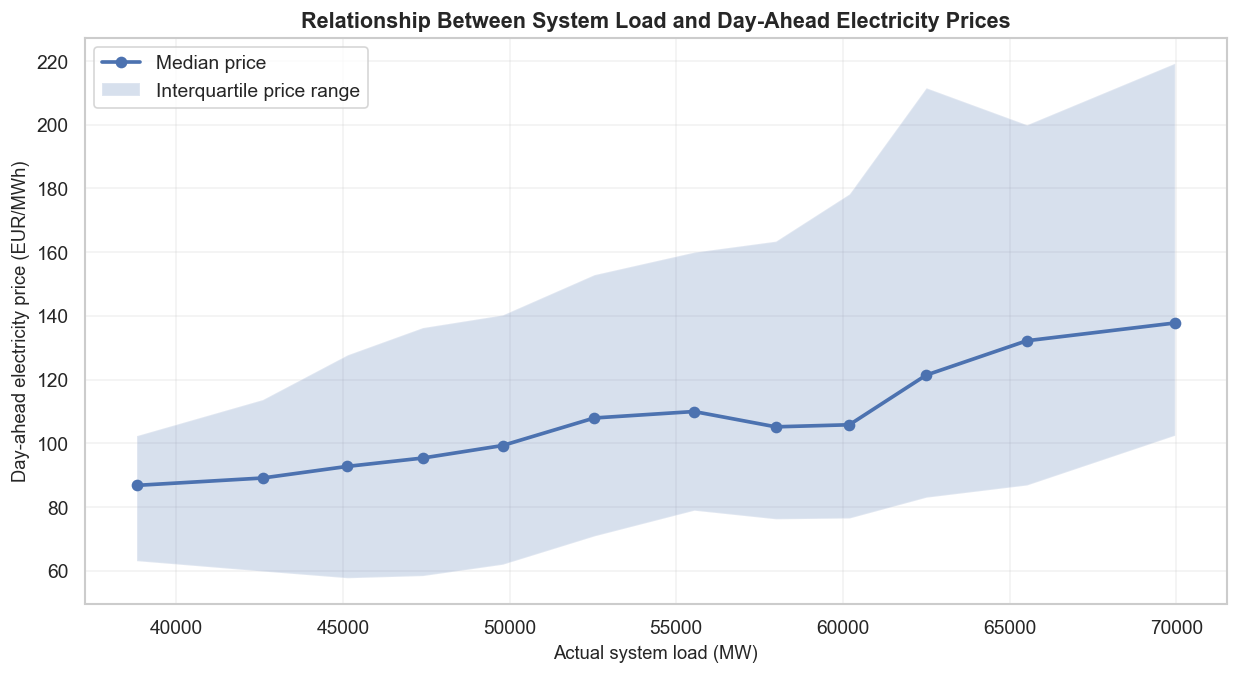

Saved: C:\Users\SherM\OneDrive\Documents\1. Thesis\Figures\EDA_v2\08_load_vs_price_binned.png


In [22]:
plot_binned_relationship(
    df_eda, "load", price_col,
    "Actual system load (MW)",
    "Relationship Between System Load and Day-Ahead Electricity Prices",
    "08_load_vs_price_binned.png"
)


## Figure 6. Renewable share vs price

**Question:** How does renewable penetration relate to price?

`renewable_share = (wind generation + solar generation) / load`


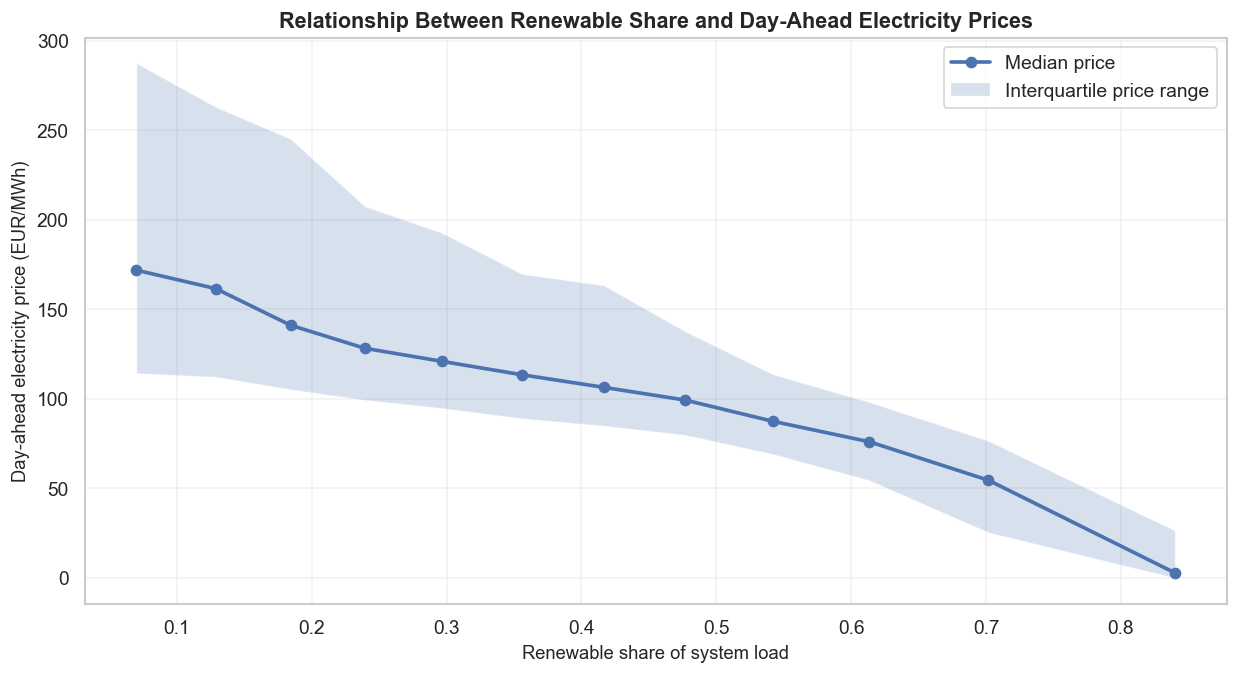

Saved: C:\Users\SherM\OneDrive\Documents\1. Thesis\Figures\EDA_v2\09_renewable_share_vs_price_binned.png


In [24]:
plot_binned_relationship(
    df_eda, "renewable_share", price_col,
    "Renewable share of system load",
    "Relationship Between Renewable Share and Day-Ahead Electricity Prices",
    "09_renewable_share_vs_price_binned.png"
)


# Part D — Feature relationships

## Figure 7. Pearson and Spearman correlation with price

- **Pearson** measures linear relationships.
- **Spearman** measures monotonic relationships.

A low Pearson value does **not** prove a variable is useless for Random Forest or XGBoost. Tree-based models can learn thresholds and interactions.


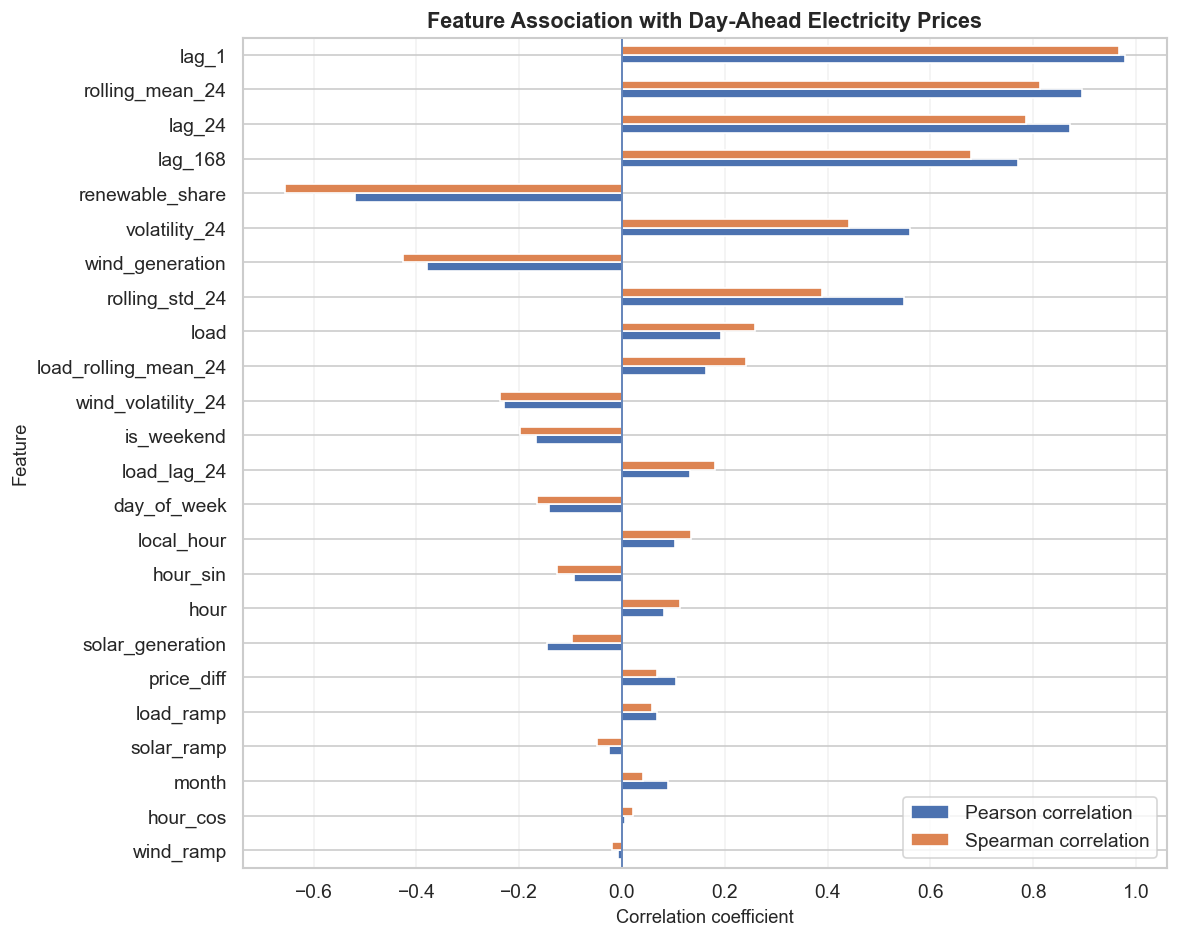

Saved: C:\Users\SherM\OneDrive\Documents\1. Thesis\Figures\EDA_v2\13_price_feature_correlations_pearson_spearman.png


In [26]:
numeric_features = df_eda.select_dtypes(include=np.number).columns.tolist()
excluded = [price_col, "price_asinh", "is_negative_price", "is_price_spike", "weekday_number", "month_number", "year"]
candidate_features = [c for c in numeric_features if c not in excluded]

pearson = df_eda[candidate_features + [price_col]].corr(method="pearson")[price_col].drop(price_col)
spearman = df_eda[candidate_features + [price_col]].corr(method="spearman")[price_col].drop(price_col)

correlation_comparison = (
    pd.DataFrame({"Pearson correlation": pearson, "Spearman correlation": spearman})
    .assign(abs_spearman=lambda x: x["Spearman correlation"].abs())
    .sort_values("abs_spearman", ascending=True)
    .drop(columns="abs_spearman")
)

fig, ax = plt.subplots(figsize=(10, 8))
correlation_comparison.plot(kind="barh", ax=ax)
ax.axvline(0, linewidth=1)
ax.set_title("Feature Association with Day-Ahead Electricity Prices")
ax.set_xlabel("Correlation coefficient")
ax.set_ylabel("Feature")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.25)
save_and_show(fig, "13_price_feature_correlations_pearson_spearman.png")


## Figure 8. Focused correlation heatmap

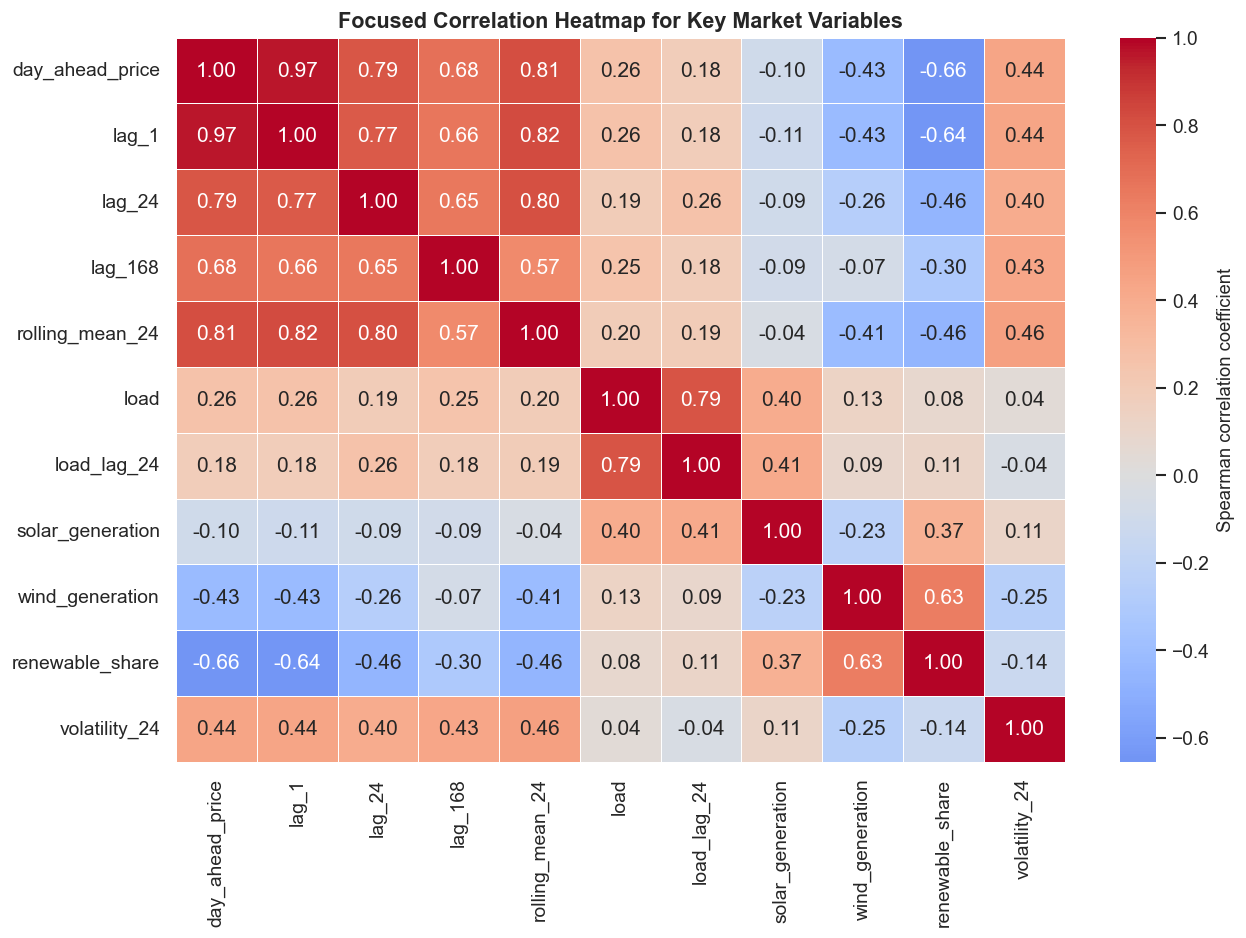

Saved: C:\Users\SherM\OneDrive\Documents\1. Thesis\Figures\EDA_v2\14_focused_feature_heatmap.png


In [28]:
focused_features = [
    price_col, "lag_1", "lag_24", "lag_168", "rolling_mean_24",
    "load", "load_lag_24", "solar_generation", "wind_generation",
    "renewable_share", "volatility_24"
]
focused_features = [c for c in focused_features if c in df_eda.columns]
focused_corr = df_eda[focused_features].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(
    focused_corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cbar_kws={"label": "Spearman correlation coefficient"},
    ax=ax
)
ax.set_title("Focused Correlation Heatmap for Key Market Variables")
save_and_show(fig, "14_focused_feature_heatmap.png")


# Part E — Volatility and time-series structure

## Figure 9. Rolling price volatility

**Question:** When did the market become more difficult to forecast?


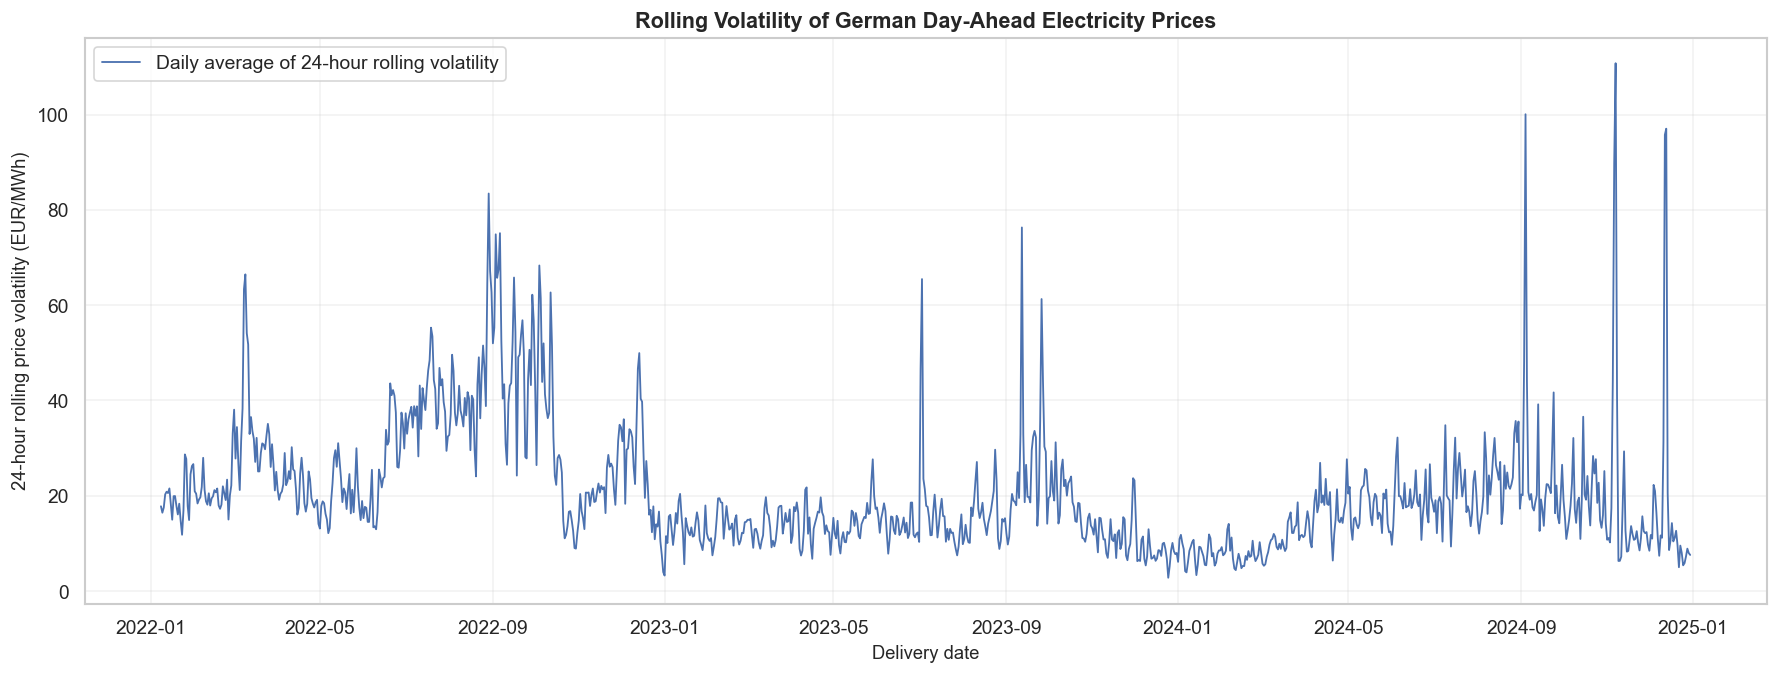

Saved: C:\Users\SherM\OneDrive\Documents\1. Thesis\Figures\EDA_v2\15_price_volatility_over_time.png


In [30]:
if "volatility_24" not in df_eda.columns:
    df_eda["volatility_24"] = df_eda[price_col].diff().rolling(24).std()

daily_volatility = df_eda["volatility_24"].resample("D").mean()

fig, ax = plt.subplots(figsize=(15, 5.8))
ax.plot(daily_volatility.index, daily_volatility, linewidth=1.1, label="Daily average of 24-hour rolling volatility")
ax.set_title("Rolling Volatility of German Day-Ahead Electricity Prices")
ax.set_xlabel("Delivery date")
ax.set_ylabel("24-hour rolling price volatility (EUR/MWh)")
ax.legend()
ax.grid(alpha=0.25)
save_and_show(fig, "15_price_volatility_over_time.png")


# Part F — Summary cards and exports

These outputs are useful for a dashboard and for the report appendix.


In [32]:
summary_cards = pd.Series({
    "Start of dataset": df_eda.index.min(),
    "End of dataset": df_eda.index.max(),
    "Hourly observations": len(df_eda),
    "Average price (EUR/MWh)": df_eda[price_col].mean(),
    "Median price (EUR/MWh)": df_eda[price_col].median(),
    "Minimum price (EUR/MWh)": df_eda[price_col].min(),
    "Maximum price (EUR/MWh)": df_eda[price_col].max(),
    "Negative-price hours": df_eda["is_negative_price"].sum(),
    "Negative-price share": df_eda["is_negative_price"].mean(),
    "Average renewable share": df_eda["renewable_share"].mean()
})
summary_cards


Start of dataset           2022-01-08 00:00:00+01:00
End of dataset             2024-12-30 23:00:00+01:00
Hourly observations                            26112
Average price (EUR/MWh)                   136.508029
Median price (EUR/MWh)                       102.845
Minimum price (EUR/MWh)                       -500.0
Maximum price (EUR/MWh)                       936.28
Negative-price hours                             823
Negative-price share                        0.031518
Average renewable share                     0.407071
dtype: object

# Optional interactive dashboard preview with Plotly

Run this section only if you want interactive charts inside Jupyter Notebook. These visualisations can later be transferred into a Streamlit or Dash dashboard.


In [34]:
import sys
!{sys.executable} -m pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.9 MB 6.9 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.9 MB 7.5 MB/s eta 0:00:02
   ------------ --------------------------- 3.1/9.9 MB 5.9 MB/s eta 0:00:02
   --------------- ------------------------ 3.9/9.9 MB 5.0 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.9 MB 5.2 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.9 MB 5.3 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 5.3 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 5.5 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   -------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\SherM\agentic-ai\.venv\Scripts\python.exe -m pip install --upgrade pip


In [35]:
import plotly.express as px

In [38]:
!{sys.executable} -m pip install nbformat ipykernel


   ---------------------------------------- 0/7 [fastjsonschema]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------- ----- 6/7 [nbformat]
   ---------------------------------------- 7/7 [nbformat]




[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\SherM\agentic-ai\.venv\Scripts\python.exe -m pip install --upgrade pip


In [42]:
interactive_daily = daily_price.reset_index()
fig = px.line(
    interactive_daily,
    x=interactive_daily.columns[0],
    y=["daily_mean", "rolling_mean_30d"],
    title="Interactive German Day-Ahead Price Trend",
    labels={
        interactive_daily.columns[0]: "Delivery date",
        "value": "Day-ahead electricity price (EUR/MWh)",
        "variable": "Series"
    }
)
fig.update_layout(hovermode="x unified")
#fig.show()
fig.show(renderer="browser")